<a href="https://colab.research.google.com/github/juliasharmankina-web/Exploratory-data-analysis-for-online-store/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Tableau Dashboard](https://public.tableau.com/app/profile/yuliia.sharmankina/viz/ExecuriveSalesTrafficDashboard/Dashboard1?publish=yes)

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import scipy.stats as stats

auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")

### SQL Query

In [ ]:
query="""
select
     s.date,
     s.ga_session_id,
     sp.browser,
     sp.channel,
     sp.continent,
     sp.country,
     sp.device,
     sp.mobile_model_name,
     sp.language,
     sp.operating_system,
     sp.medium as traffic_source,
     sp.channel as traffic_channel,
      ac.id as account_id,
      ac.is_verified as email_verified,
      ac.is_unsubscribed as unsubscribed,
      p.category,
      p.name as product_name,
      p.price,
      p.short_description


from `DA.session` s
left join `DA.session_params` sp
on s.ga_session_id = sp.ga_session_id
left join `DA.account_session` acs
on acs.ga_session_id = s.ga_session_id
left join `DA.account` ac
on ac.id = acs.account_id
left join `DA.order` o
on s.ga_session_id = o.ga_session_id
left join `DA.product` p
on o.item_id = p.item_id
"""
df = client.query(query).result().to_dataframe(create_bqstorage_client=False)
df.head()

,date,ga_session_id,browser,channel,continent,country,device,mobile_model_name,language,operating_system,traffic_source,traffic_channel,account_id,email_verified,unsubscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Chrome,Paid Search,Americas,United States,desktop,Safari,zh,Macintosh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Chrome,Organic Search,Europe,United Kingdom,desktop,Chrome,en-us,Web,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Chrome,Direct,Europe,Norway,mobile,<Other>,zh,Web,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Chrome,Direct,Africa,Nigeria,mobile,<Other>,es-es,Android,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Chrome,Direct,Asia,China,desktop,Chrome,en-us,Windows,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
# checking number of rows and columns in the table
df.shape

(349545, 19)

In [ ]:
# checking information the table contains, data types, presence of missed values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   browser            349545 non-null  object 
 3   channel            349545 non-null  object 
 4   continent          349545 non-null  object 
 5   country            349545 non-null  object 
 6   device             349545 non-null  object 
 7   mobile_model_name  349545 non-null  object 
 8   language           235279 non-null  object 
 9   operating_system   349545 non-null  object 
 10  traffic_source     349545 non-null  object 
 11  traffic_channel    349545 non-null  object 
 12  account_id         27945 non-null   Int64  
 13  email_verified     27945 non-null   Int64  
 14  unsubscribed       27945 non-null   Int64  
 15  category           33538 non-null   object 
 16  pr

In [ ]:
# unique sessions count
df['ga_session_id'].nunique()

349545

In [ ]:
# min and max date of unique sessions
min_date = df['date'].min()
max_date = df['date'].max()
print(f"Period: from {min_date} to {max_date}")

Period: from 2020-11-01 to 2021-01-31


In [ ]:
#checking amount of missing values in each column
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
print(missing_values)

account_id           321600
email_verified       321600
unsubscribed         321600
category             316007
price                316007
product_name         316007
short_description    316007
language             114266
dtype: int64


In [ ]:
#checking share of the missed values:
print(missing_values/ df.shape[0] * 100)

account_id           92.005321
email_verified       92.005321
unsubscribed         92.005321
category             90.405241
price                90.405241
product_name         90.405241
short_description    90.405241
language             32.689925
dtype: float64


In [ ]:
# cleaning missing values in the calumns
df.dropna(subset=['price'], inplace=True)
df.dropna(subset=['product_name'], inplace=True)


In [ ]:
#checking df for missing values again
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
print(missing_values)

account_id        30757
email_verified    30757
unsubscribed      30757
language          11007
dtype: int64


In [ ]:
#Top 3 continents and top 5 countries by sales and orders
top_3_continents = df.groupby('continent')['price'].sum().nlargest(3)
print(f"Top 3 continents by sales: {top_3_continents}")
print()

top_5_countries = df.groupby('country')['price'].sum().nlargest(5)
print(f"Top 5 countries by sales: {top_5_countries}")
print()

top_3_continents_orders = df.groupby('continent')['ga_session_id'].count().nlargest(3)
print(f"Top 3 continents by orders: {top_3_continents_orders}")
print()

top_5_countries_orders = df.groupby('country')['ga_session_id'].count().nlargest(5)
print(f"Top 5 countries by orders: {top_5_countries_orders}")
print()

#top 10 categories by  and sales
top_10_categories = df.groupby('category')['price'].sum().nlargest(10)
print(f"Top 10 categories by sales: {top_10_categories}")
print()

#top 10 categories by country with the largest sales
top_10_categories_country = df.groupby(['country', 'category'])['price'].sum().nlargest(10)
print(f"Top 10 categories by country with the largest sales: {top_10_categories_country}")
print()

# top 10 categories by sales by top country

if 'country' in df.columns:
  top_country = df.groupby('country')['price'].sum().nlargest(1)
  top_country_name = top_country.index[0]
  top_10_categories_top_country = df[df['country'] == top_country_name].groupby('category')['price'].sum().nlargest(10)

print(f"Top 10 categories by sales in {top_country_name}: {top_10_categories_top_country}")
print()


Top 3 continents by sales: continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64

Top 5 countries by sales: country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64

Top 3 continents by orders: continent
Americas    18553
Asia         7950
Europe       6261
Name: ga_session_id, dtype: Int64

Top 5 countries by orders: country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Name: ga_session_id, dtype: Int64

Top 10 categories by sales: category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks             

In [ ]:
# top 10 categories by sales by top country
top_country = []
if 'country' in df.columns:
  top_country = df.groupby('country')['price'].sum().nlargest(1)
  top_country_name = top_country.index[0]
  top_10_categories_top_country = df[df['country'] == top_country_name].groupby('category')['price'].sum().nlargest(10)
  print(f"Top 10 categories by sales in {top_country_name}: {top_10_categories_top_country}")
  print()

Top 10 categories by sales in United States: category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64



/tmp/ipykernel_2312/3257143479.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette="viridis")


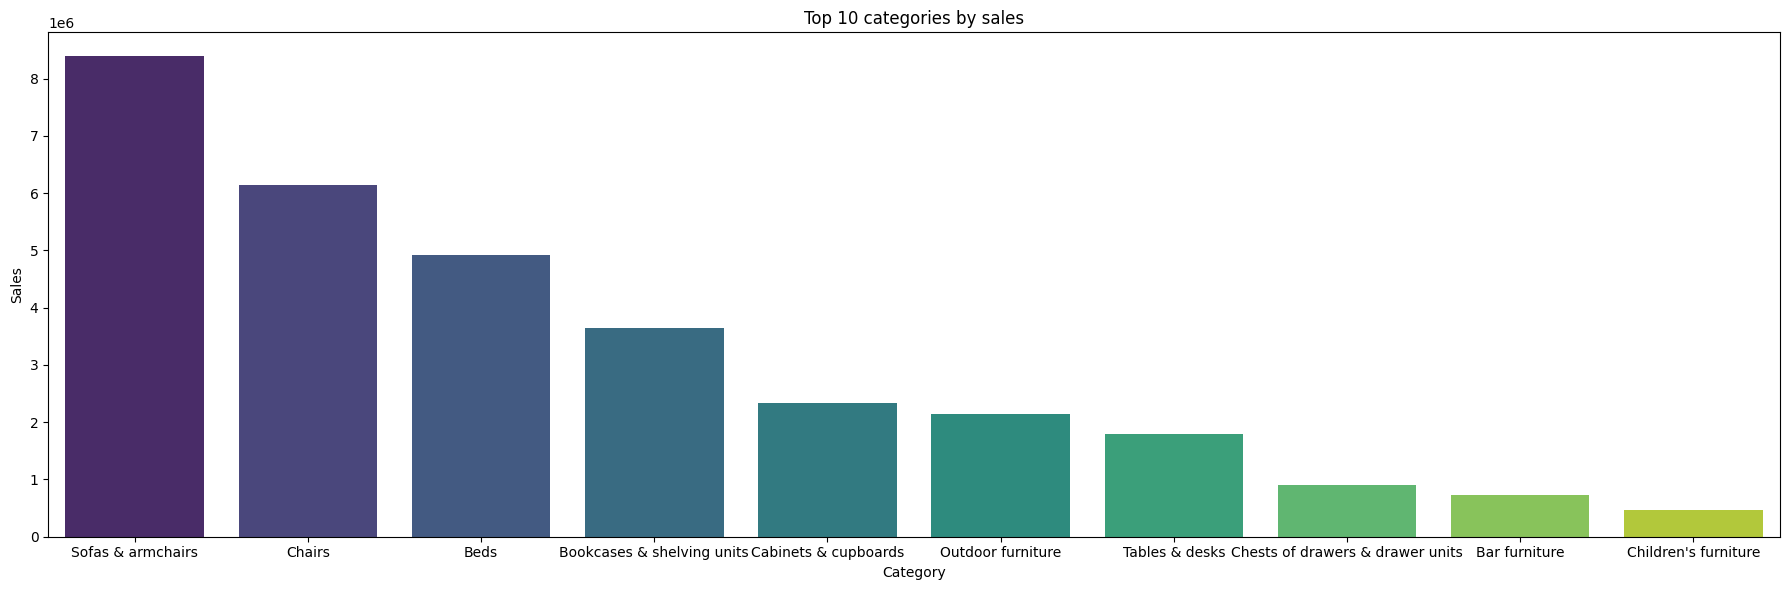

In [ ]:
# creating barchart to compare categories
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(18, 6))
sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette="viridis")
plt.title("Top 10 categories by sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

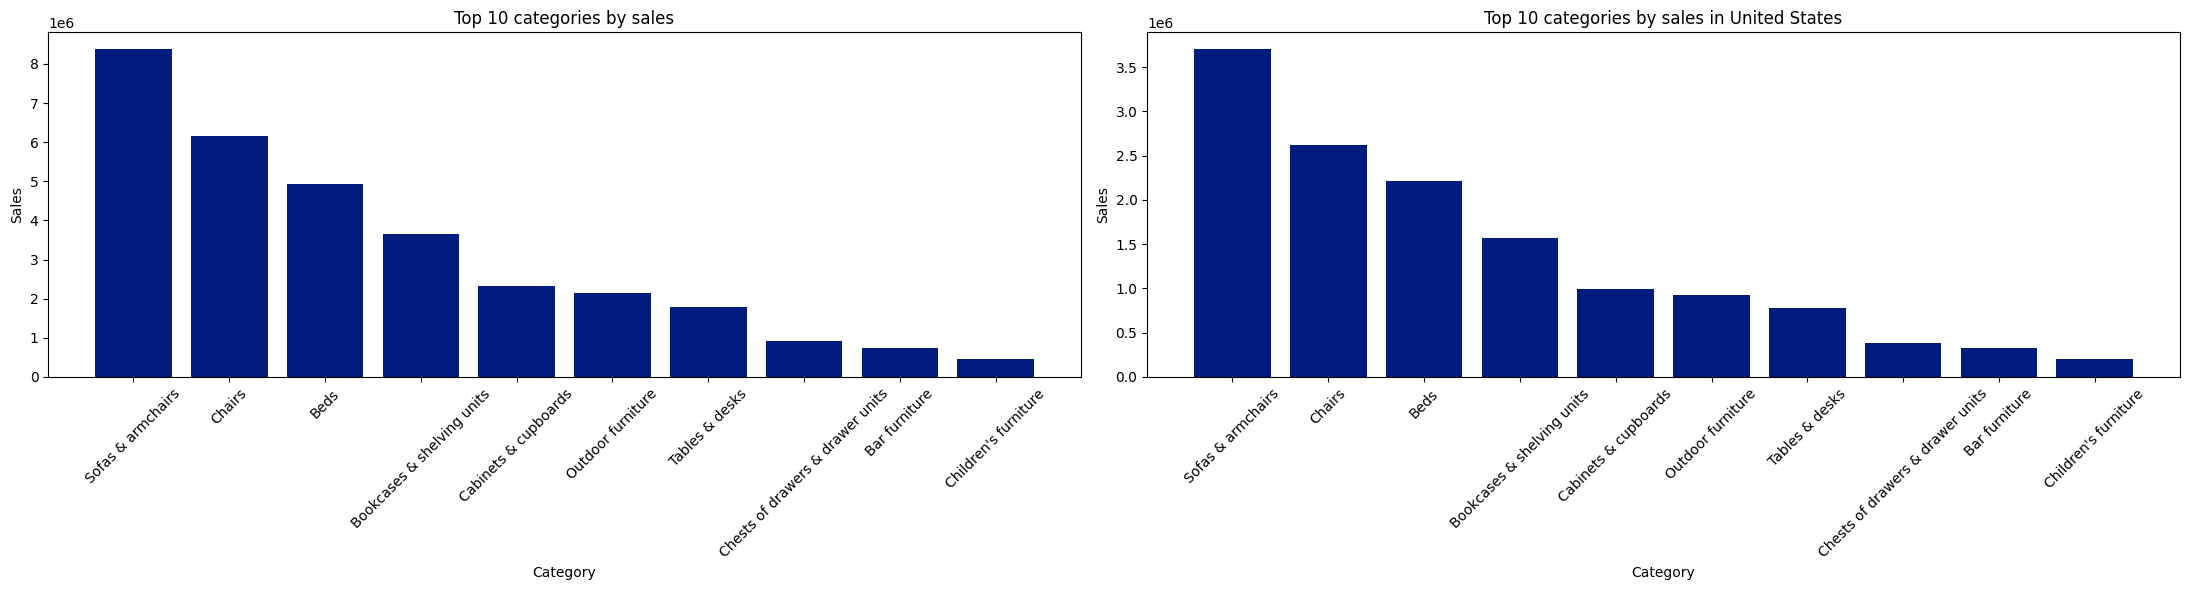

In [ ]:
# Create bar charts to compare categories
import numpy as np
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(1, 2, figsize=(22, 6))
plt.style.use("seaborn-v0_8-dark-palette")


# Plot the first bar chart
ax[0].bar(top_10_categories.index, top_10_categories.values)
ax[0].set_title("Top 10 categories by sales")
ax[0].set_xlabel("Category")
ax[0].set_ylabel("Sales")
ax[0].tick_params(axis='x', rotation=45)

# Plot the second bar chart - Top 10 categories by sales for the country with the largest sales
# This relies on 'top_country_name' and 'top_10_categories_top_country' being defined from previous cells.
if 'top_country_name' in locals() and 'top_10_categories_top_country' in locals() and not top_10_categories_top_country.empty:
    ax[1].bar(top_10_categories_top_country.index, top_10_categories_top_country.values)
    ax[1].set_title(f"Top 10 categories by sales in {top_country_name}")
    ax[1].set_xlabel("Category")
    ax[1].set_ylabel("Sales")
    ax[1].tick_params(axis='x', rotation=45)
else:
    ax[1].set_title("Top 10 categories for highest sales country (Data Not Found or Calculated)")
    ax[1].set_xlabel("Category")
    ax[1].set_ylabel("Sales")

# Adjust layout
plt.tight_layout()

plt.show()

In [ ]:
# sales by types and models of devices (in % of total sales)
total_sales = df['price'].sum()

sales_by_device = df.groupby('device')['price'].sum()
sales_by_device_percent = (sales_by_device / total_sales) * 100
print(f"Sales by device (in % of total sales):\n{sales_by_device_percent.round(2)}")
print()

sales_by_model = df.groupby('mobile_model_name')['price'].sum()
sales_by_model_percent = (sales_by_model / total_sales) * 100
print(f"Sales by model (in % of total sales):\n{sales_by_model_percent.round(2)}")
print()

# sales by traffic source (in % of total sales)
sales_by_traffic_source = df.groupby('traffic_source')['price'].sum()
sales_by_traffic_source_percent = (sales_by_traffic_source / total_sales) * 100
print(f"Sales by traffic source (in % of total sales):\n{sales_by_traffic_source_percent.round(2)}")
print()

# percentage of registered users who verified their email
registered_users_df = df[df['account_id'].notna()]
# Considering each ga_session_id as a unique session for a registered user for this calculation
total_registered_user_sessions = registered_users_df['ga_session_id'].nunique()
verified_email_sessions = registered_users_df[registered_users_df['email_verified'] == 1]['ga_session_id'].nunique()

if total_registered_user_sessions > 0:
    percentage_verified = (verified_email_sessions / total_registered_user_sessions) * 100
    print(f"Percentage of registered user sessions with verified email: {round(percentage_verified, 2)}%")
else:
    print("No registered user sessions found to calculate email verification percentage.")
print()

# percentage of registrated users who unsubscribed from newsletter?
unsubscribed_sessions = registered_users_df[registered_users_df['unsubscribed'] == 1]['ga_session_id'].nunique()

if total_registered_user_sessions > 0:
    percentage_unsubscribed = (unsubscribed_sessions / total_registered_user_sessions) * 100
    print(f"Percentage of registered user sessions who unsubscribed from newsletter: {round(percentage_unsubscribed, 2)}%")
else:
    print("No registered user sessions found to calculate unsubscription percentage.")
print()

#top countries by registrated users
top_countries_registered_users = registered_users_df.groupby('country')['ga_session_id'].nunique().nlargest(5)
print(f"Top 5 countries by registered users:\n{top_countries_registered_users}")


Sales by device (in % of total sales):
device
desktop    59.00
mobile     38.73
tablet      2.26
Name: price, dtype: float64

Sales by model (in % of total sales):
mobile_model_name
<Other>       20.44
Chrome        27.84
ChromeBook     5.73
Edge           2.18
Firefox        1.32
Pixel 3        0.34
Pixel 4 XL     0.37
Safari        20.30
iPad           1.40
iPhone        20.08
Name: price, dtype: float64

Sales by traffic source (in % of total sales):
traffic_source
(data deleted)     6.39
(none)            23.44
<Other>           14.05
cpc                4.27
organic           34.20
referral          17.65
Name: price, dtype: float64

Percentage of registered user sessions with verified email: 71.52%

Percentage of registered user sessions who unsubscribed from newsletter: 16.07%

Top 5 countries by registered users:
country
United States     1207
India              246
Canada             207
United Kingdom      88
France              56
Name: ga_session_id, dtype: int64


In [ ]:
sales_by_model = df.groupby('mobile_model_name')['price'].sum()
sales_by_model_percent = (sales_by_model / total_sales) * 100
if (sales_by_model_percent < 2.5).any():
  sales_by_model_percent = pd.concat([sales_by_model_percent[sales_by_model_percent >= 2.5], pd.Series([sales_by_model_percent[sales_by_model_percent < 2.5].sum()], index=['Other'])])

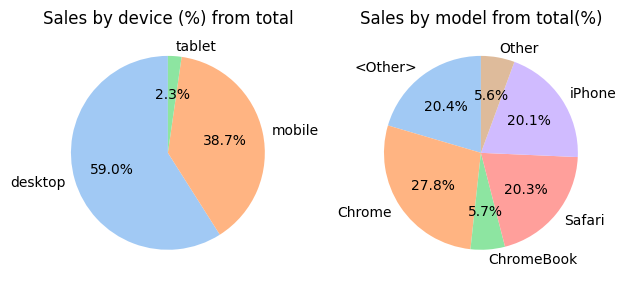

(array([], dtype=float64), [])

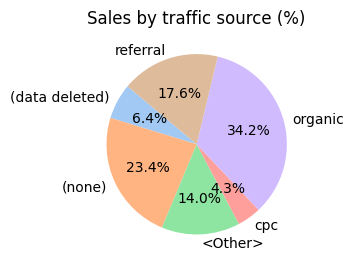

In [ ]:
#creating pie charts
plt.subplot(1, 2, 1)
sales_by_device_percent.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
plt.title('Sales by device (%) from total')
plt.ylabel(' ')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sales_by_model_percent.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
plt.title('Sales by model from total(%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

plt.subplot(1, 2, 1)
sales_by_traffic_source_percent.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Sales by traffic source (%)')
plt.ylabel(' ')
plt.xticks(rotation=0)


### Comparison of Sales Behavior between Subscribed and Unsubscribed Users


In [ ]:
subscribed_users_df = registered_users_df[registered_users_df['unsubscribed'] == 0]
unsubscribed_users_df = registered_users_df[registered_users_df['unsubscribed'] == 1]

total_sales_subscribed = subscribed_users_df['price'].sum()
total_sales_unsubscribed = unsubscribed_users_df['price'].sum()

total_sessions_subscribed = subscribed_users_df['ga_session_id'].nunique()
total_sessions_unsubscribed = unsubscribed_users_df['ga_session_id'].nunique()

avg_sales_per_session_subscribed = total_sales_subscribed / total_sessions_subscribed if total_sessions_subscribed > 0 else 0
avg_sales_per_session_unsubscribed = total_sales_unsubscribed / total_sessions_unsubscribed if total_sessions_unsubscribed > 0 else 0

print(f"Total sales for subscribed users: {total_sales_subscribed:.2f}")
print(f"Average sales per session for subscribed users: {avg_sales_per_session_subscribed:.2f}")
print()
print(f"Total sales for unsubscribed users: {total_sales_unsubscribed:.2f}")
print(f"Average sales per session for unsubscribed users: {avg_sales_per_session_unsubscribed:.2f}")

print("\n--- Summary ---")
if total_sales_subscribed > total_sales_unsubscribed:
    print("Subscribed users generate more total sales.")
elif total_sales_unsubscribed > total_sales_subscribed:
    print("Unsubscribed users generate more total sales.")
else:
    print("Total sales are similar for both groups.")

if avg_sales_per_session_subscribed > avg_sales_per_session_unsubscribed:
    print("Subscribed users have higher average sales per session.")
elif avg_sales_per_session_unsubscribed > avg_sales_per_session_subscribed:
    print("Unsubscribed users have higher average sales per session.")
else:
    print("Average sales per session are similar for both groups.")


Total sales for subscribed users: 2150796.90
Average sales per session for subscribed users: 921.51

Total sales for unsubscribed users: 431721.60
Average sales per session for unsubscribed users: 965.82

--- Summary ---
Subscribed users generate more total sales.
Unsubscribed users have higher average sales per session.


###Analysis of sales trends

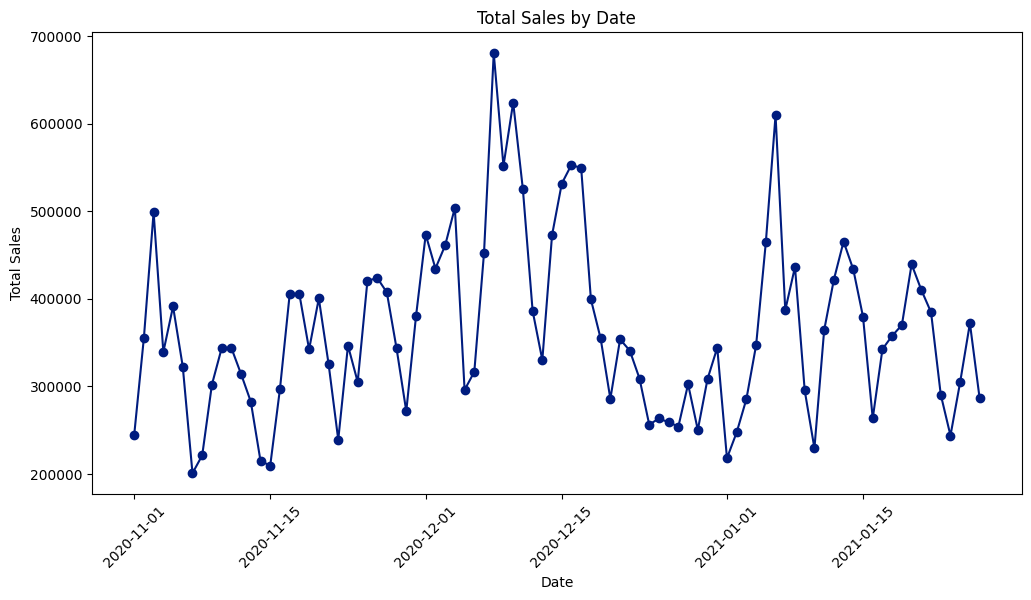

In [ ]:
# Visualisation of total sales dynamics
total_sales_by_date = df.groupby('date')['price'].sum()

plt.figure(figsize=(12, 6))
plt.plot(total_sales_by_date.index, total_sales_by_date.values, marker='o')
plt.title('Total Sales by Date')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

###Analysis of seasonal trends by day of the week

/tmp/ipykernel_2312/716287474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day_of_week.index, y=sales_by_day_of_week.values, palette='viridis')


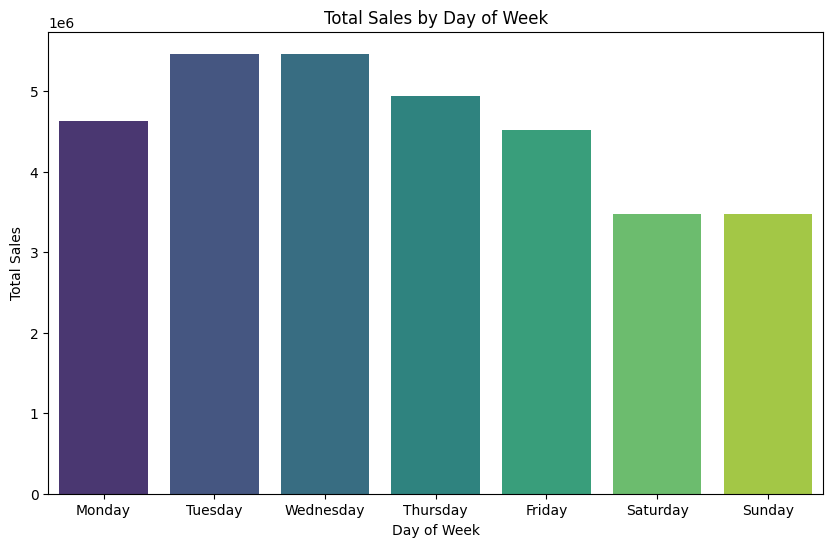

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()

sales_by_day_of_week = df.groupby('day_of_week')['price'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_day_of_week.index, y=sales_by_day_of_week.values, palette='viridis')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()


###Conclusion:

As shown in the graph, sales are generally higher in the middle of the week (Tuesday and Wednesday show the highest sales), and then they decline towards the weekend (Saturday and Sunday have the lowest sales). These are daily fluctuations, but data covering a longer period is needed to identify annual or quarterly seasonal patterns

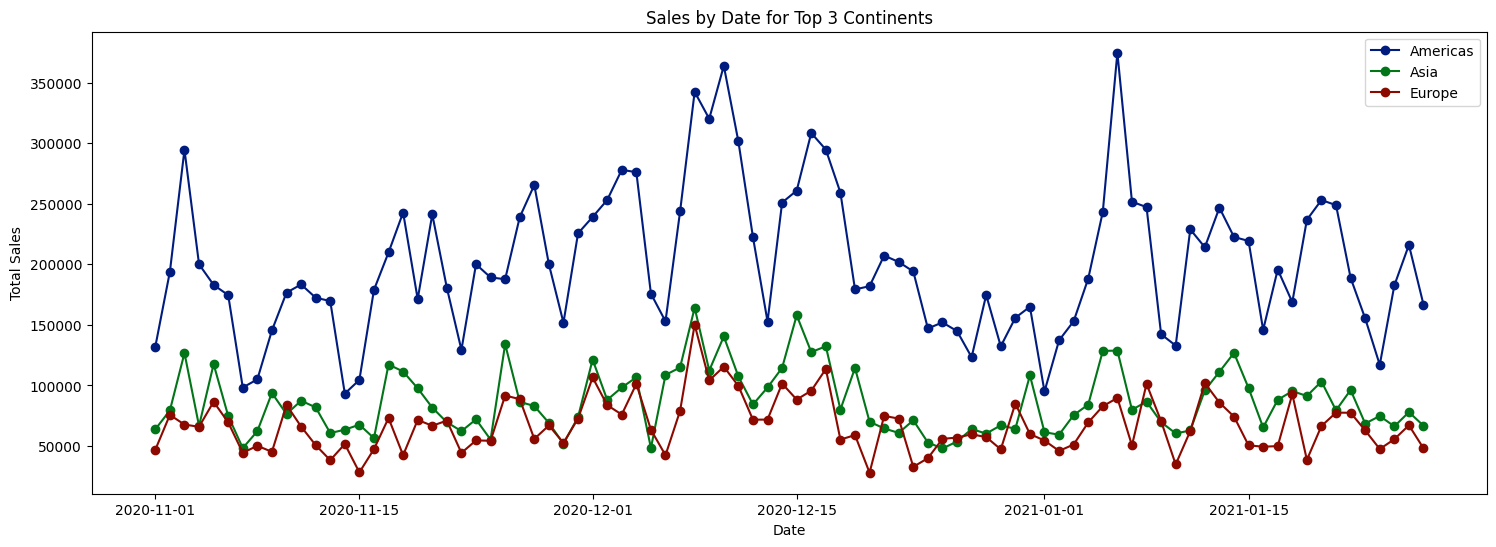

In [ ]:
#dynamics of sales by continents
sales_by_date_top_3_continents = df[df['continent'].isin(top_3_continents.index)].groupby(['date', 'continent'])['price'].sum()

plt.figure(figsize=(18, 6))
for continent in top_3_continents.index:
    continent_data = sales_by_date_top_3_continents.xs(continent, level='continent')
    plt.plot(continent_data.index, continent_data.values, label=continent, marker='o')

plt.title('Sales by Date for Top 3 Continents')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()



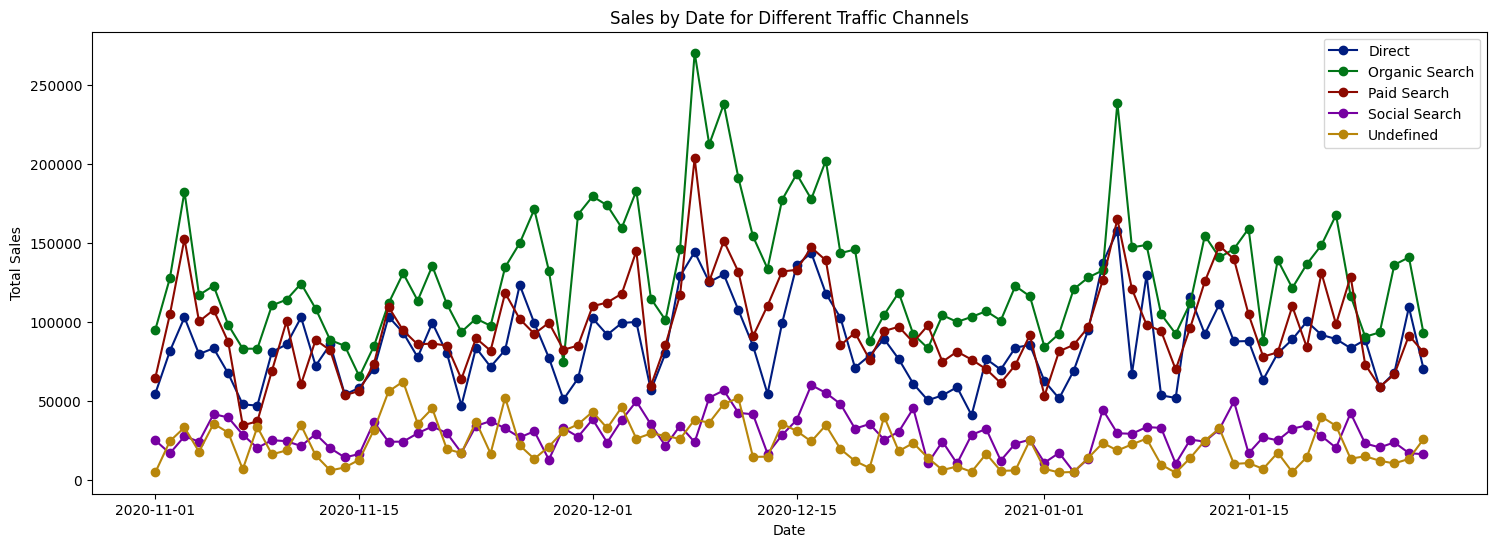

In [ ]:
#Sales trends by traffic channel
sales_by_date_traffic_channel = df.groupby(['date', 'traffic_channel'])['price'].sum()

plt.figure(figsize=(18, 6))
for channel in sales_by_date_traffic_channel.index.get_level_values('traffic_channel').unique():
    channel_data = sales_by_date_traffic_channel.xs(channel, level='traffic_channel')
    plt.plot(channel_data.index, channel_data.values, label=channel, marker='o')

plt.title('Sales by Date for Different Traffic Channels')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

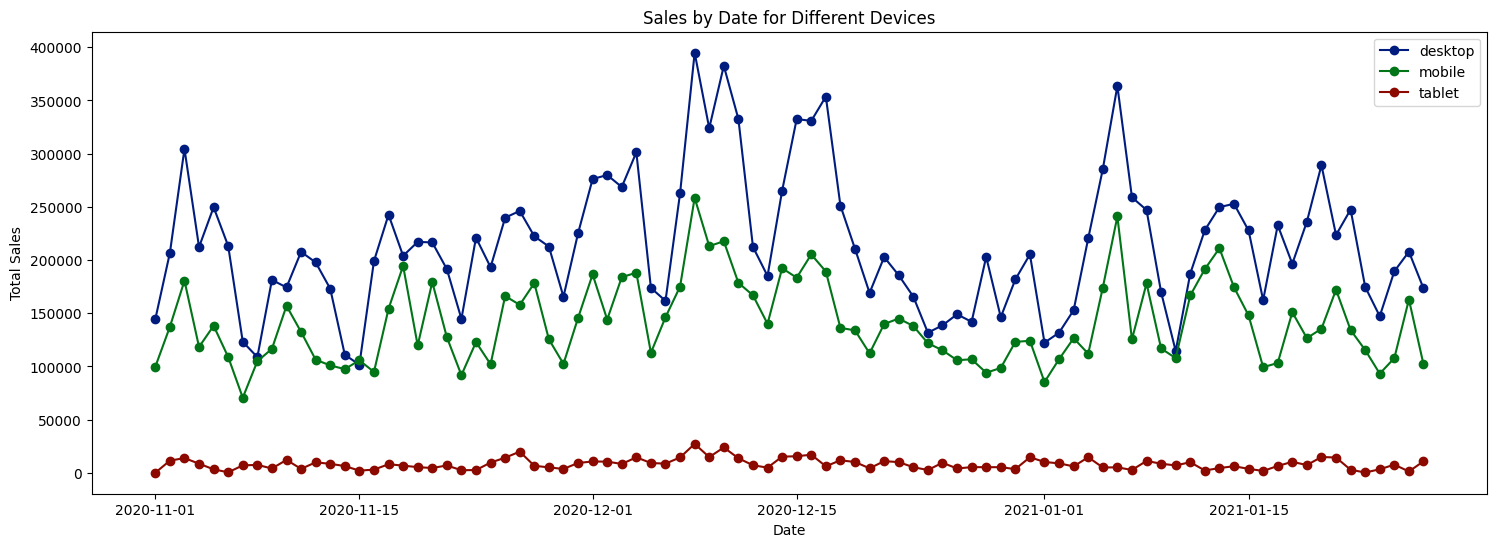

In [ ]:
# Sales dynamics by device
sales_by_date_device = df.groupby(['date', 'device'])['price'].sum()

plt.figure(figsize=(18, 6))
for device in sales_by_date_device.index.get_level_values('device').unique():
    device_data = sales_by_date_device.xs(device, level='device')
    plt.plot(device_data.index, device_data.values, label=device, marker='o')

plt.title('Sales by Date for Different Devices')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

###Conclusions

Based on the various visualizations and statistical tests performed, here are the key conclusions regarding dynamics and trends:

*   **Sales Trends and Sessions:** There is a strong relationship between the number of unique sessions and total sales. This indicates that as website traffic (sessions) increases, sales volume tends to increase proportionally, as visually confirmed by the scatter plot.

*   **Sales by Continents:** Daily sales trends across the top 3 continents (Americas, Asia, and Europe) show similar patterns. This suggests that market factors or global events might influence sales across these regions in a similar manner, leading to similar daily sales dynamics as observed in the time series plots.

*   **Sales Seasonality:** Weekly sales analysis revealed fluctuations, but more data is needed to identify annual or quarterly seasonal patterns. The daily sales dynamics across all traffic channels, continents, and devices showed similar patterns, with peaks and dips often occurring around the same dates.

*   **Traffic Channel Sales Dynamics:** Sales from different traffic channels often show similar daily patterns. This indicates that sales in these channels often move together, suggesting common underlying drivers affecting their day-to-day performance.

###Pivot tables

In [ ]:
# Creating a pivot table to sum sessions by by traffic channel and devices
pivot_table = pd.pivot_table(df, values="ga_session_id", index="traffic_channel", columns="device", aggfunc="sum")
print(pivot_table)

device                  desktop          mobile         tablet
traffic_channel                                               
Direct           22797890415794  14718592720251   760098263894
Organic Search   35025785159574  23121713046822  1245813776015
Paid Search      26139026670839  17756898819869  1043450334636
Social Search     7792542298921   5352265646024   296472149559
Undefined         5940749294692   4309415265630   212125248841


In [ ]:
# Creating a pivot table to sum total sales by top 10 categories and top 5 countries
top_10_categories_names = df.groupby('category')['price'].sum().nlargest(10).index
top_5_countries_names = df.groupby('country')['price'].sum().nlargest(5).index

# Filter the DataFrame to include only the top categories and countries
df_filtered_pivot = df[df['category'].isin(top_10_categories_names) & \
                       df['country'].isin(top_5_countries_names)]

pivot_table = pd.pivot_table(df_filtered_pivot, values="price",
                             index="category", columns="country",
                             aggfunc="sum", fill_value=0)
print(pivot_table)

country                             Canada    France     India  \
category                                                         
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0   39177.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Sofas & armchairs                 692427.5  187735.0  788430.0   
Tables & desks                    132678.0   42299.0  186157.5   

country                           United Kingdom  United States  
category                                                         
Bar furniture                            22103.0       330805.0  
Beds     

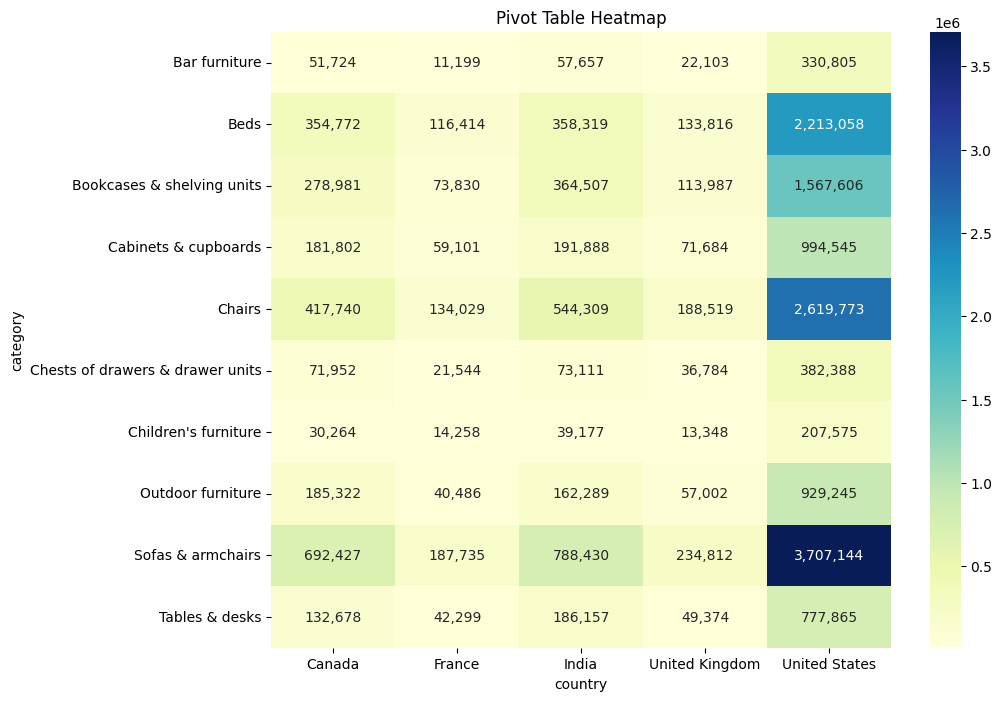

In [ ]:
# Function to format numbers as 10,000 or 10k
def format_sales(value):
    if pd.isna(value):
        return ""
    value = int(value)
    if value >= 1000:
        if value % 1000 == 0:
            return f'{value // 1000}k'
        else:
            return f'{value:,}'
    return f'{value}'

# Create a copy to apply formatting for display
pivot_table_formatted = pivot_table.copy()
for col in pivot_table_formatted.columns:
    pivot_table_formatted[col] = pivot_table_formatted[col].apply(format_sales)

plt.figure(figsize=(10,8))
sns.heatmap(pivot_table, annot=pivot_table_formatted, cmap="YlGnBu", fmt='s') # Use fmt='s' for string annotations
plt.title("Pivot Table Heatmap")
plt.show()

###Statistical analysis of correlations

In [ ]:
#Finding the number of sessions and total sales for each date.

sales_for_each_date = df.groupby('date')['price'].sum()
print(f"Total sales for each date:\n{sales_for_each_date}")
print()

sessions_for_each_date = df.groupby('date')['ga_session_id'].nunique()
print(f"Number of sessions for each date:\n{sessions_for_each_date}")



Total sales for each date:
date
2020-11-01    244292.5
2020-11-02    355506.8
2020-11-03    498979.6
2020-11-04    339187.1
2020-11-05    391276.6
                ...   
2021-01-23    290605.5
2021-01-24    243818.4
2021-01-25    305089.3
2021-01-26    372057.3
2021-01-27    286340.7
Name: price, Length: 88, dtype: float64

Number of sessions for each date:
date
2020-11-01    281
2020-11-02    368
2020-11-03    561
2020-11-04    370
2020-11-05    388
             ... 
2021-01-23    313
2021-01-24    296
2021-01-25    370
2021-01-26    385
2021-01-27    299
Name: ga_session_id, Length: 88, dtype: int64


In [ ]:
#Pearson's correlation coefficient

import pandas as pd
from scipy.stats import pearsonr

stats_data = df.groupby('date').agg({
    'ga_session_id': 'nunique',
    'price': 'sum'
}).reset_index()

# Calculate Pearson correlation
correlation, p_value = pearsonr(stats_data['ga_session_id'], stats_data['price'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"p-value: {p_value}")

Pearson correlation coefficient: 0.9642422533124871
p-value: 2.24477831491671e-51


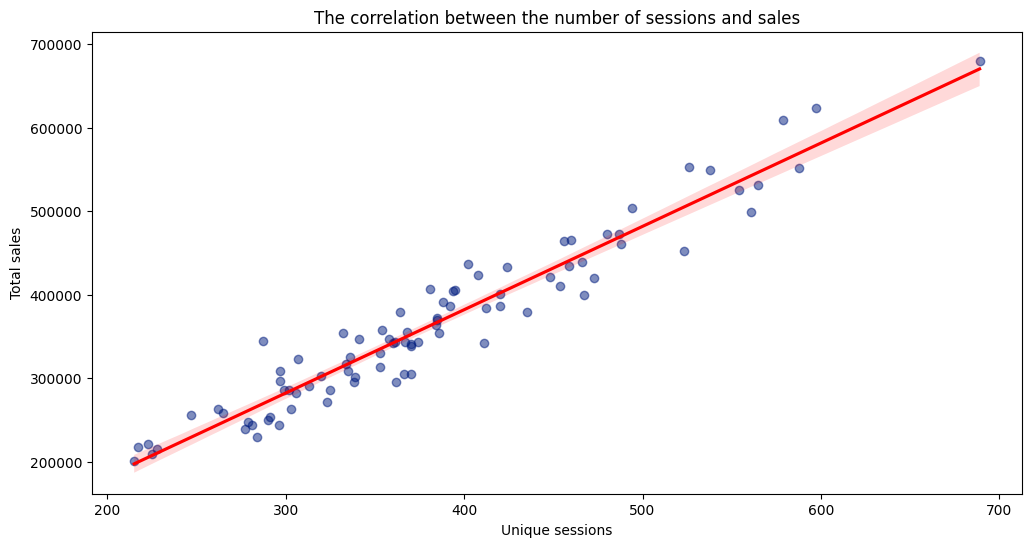

In [ ]:
#creating visualization to check the correlation between sales and sessions
plt.figure(figsize=(12, 6))
sns.regplot(data=stats_data, x='ga_session_id', y='price', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('The correlation between the number of sessions and sales')
plt.xlabel('Unique sessions')
plt.ylabel('Total sales')
plt.show()

###**Conclusion: Correlation Analysis**

The analysis reveals an extremely strong positive linear relationship between sessions and sales, with a Pearson Correlation Coefficient of approximately **0.964**. This value, being so close to +1, demonstrates that the two variables change almost in perfect synchronization: as sessions increase, sales volume is almost guaranteed to rise as well.

The statistical significance is confirmed by a p-value of 2.24×10
−51
 , which is effectively zero. Since this is significantly below the 0.05 threshold, we can conclude with full confidence that the relationship is not due to random chance. The scatterplot further validates these findings, showing a tight clustering of data points along the regression line, confirming a highly reliable and statistically significant correlation.

Total sales by continent:
continent
(not set)       74067.4
Africa         331231.0
Americas     17665280.0
Asia          7601298.3
Europe        5934624.2
Oceania        365230.2
Name: price, dtype: float64


Pairwise Pearson correlations between daily sales of top 3 continents:
  Americas vs. Europe: r = 0.67, p-value = 9.911e-13
  Americas vs. Asia: r = 0.69, p-value = 8.004e-14
  Europe vs. Asia: r = 0.67, p-value = 1.191e-12


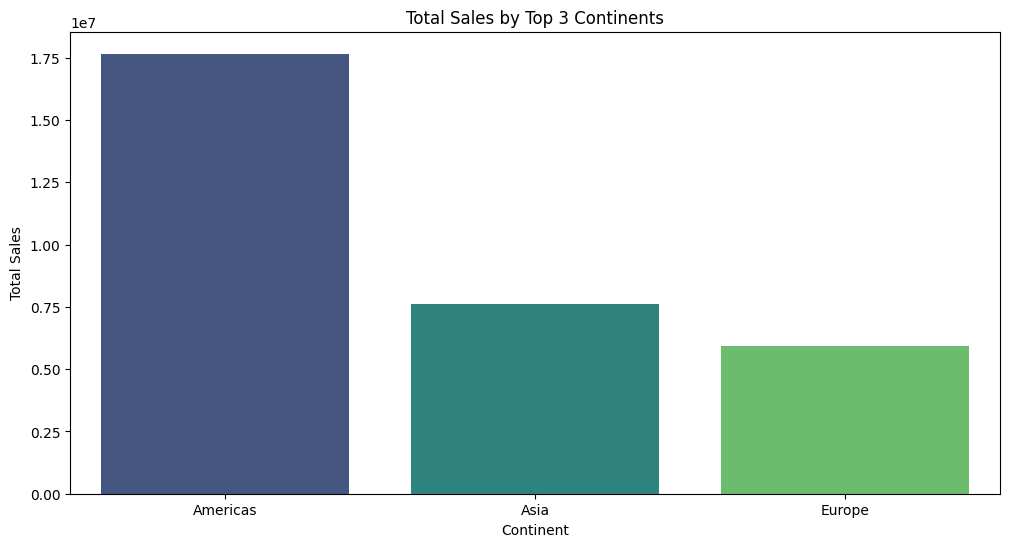

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# The correlation between sales on different continents

# Calculate total sales by continent (for overview)
sales_by_continent = df.groupby('continent')['price'].sum()
print(f"Total sales by continent:\n{sales_by_continent}")
print()

# --- Addressing the correlation between continents' sales trends ---
# Pearson correlation is not applicable between categorical continent names and sales values.
# Instead, we can correlate the daily sales trends *between* different continents.

# We previously computed sales_by_date_top_3_continents in cell sJs98Flntdnx.
# Reshape this data to have continents as columns and date as index
if 'sales_by_date_top_3_continents' in locals():
    sales_pivot = sales_by_date_top_3_continents.unstack(level='continent')

    print("\nPairwise Pearson correlations between daily sales of top 3 continents:")

    # Correlate sales between Americas and Europe
    correlation_am_eu, p_value_am_eu = pearsonr(sales_pivot['Americas'], sales_pivot['Europe'])
    print(f"  Americas vs. Europe: r = {correlation_am_eu:.2f}, p-value = {p_value_am_eu:.3e}")

    # Correlate sales between Americas and Asia
    correlation_am_as, p_value_am_as = pearsonr(sales_pivot['Americas'], sales_pivot['Asia'])
    print(f"  Americas vs. Asia: r = {correlation_am_as:.2f}, p-value = {p_value_am_as:.3e}")

    # Correlate sales between Europe and Asia
    correlation_eu_as, p_value_eu_as = pearsonr(sales_pivot['Europe'], sales_pivot['Asia'])
    print(f"  Europe vs. Asia: r = {correlation_eu_as:.2f}, p-value = {p_value_eu_as:.3e}")
else:
    print("Could not compute inter-continent correlations: 'sales_by_date_top_3_continents' not found.")

# --- Visualization of total sales by top 3 continents ---
plt.figure(figsize=(12, 6))
sns.barplot(x=top_3_continents.index, y=top_3_continents.values, hue=top_3_continents.index, palette='viridis', legend=False)
plt.title('Total Sales by Top 3 Continents')
plt.xlabel('Continent')
plt.ylabel('Total Sales')
plt.show()

###Statistical analysis of differences between groups



### Statistical comparison of sales between registered and unregistered users

Number of sales records for registered users: 2781
Number of sales records for unregistered users: 30757


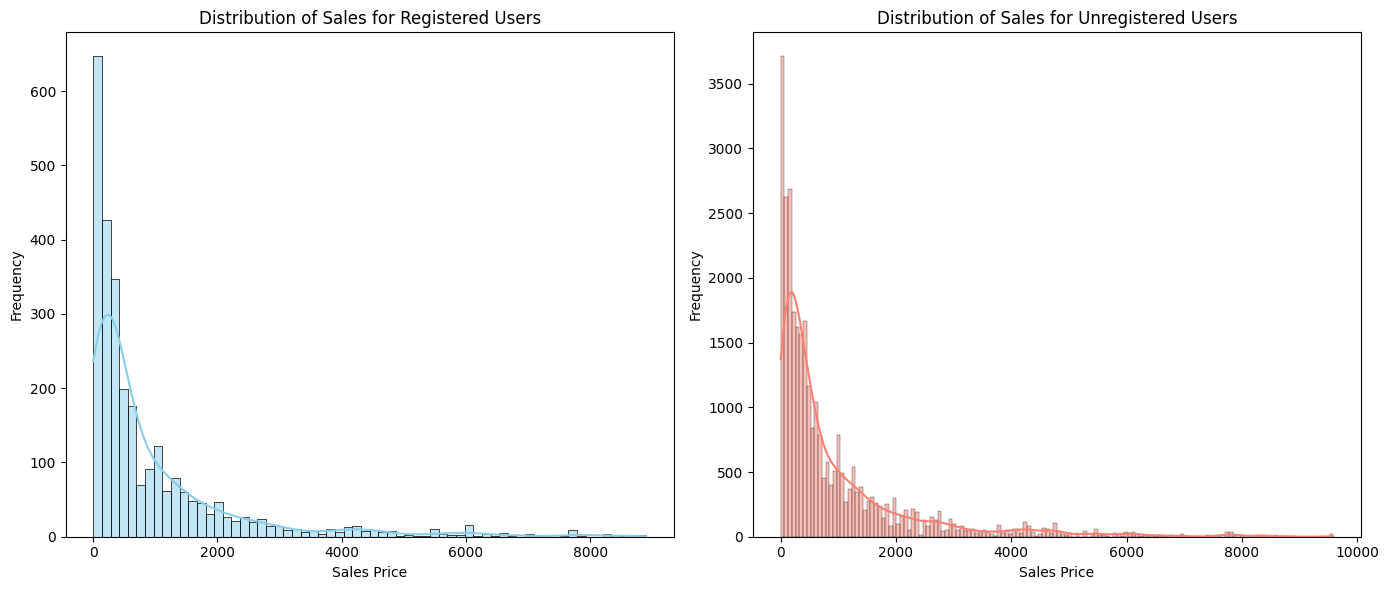

In [ ]:
# Define registered and unregistered users
registered_users_sales = df[df['account_id'].notna()]['price'].dropna()
unregistered_users_sales = df[df['account_id'].isna()]['price'].dropna()

print(f"Number of sales records for registered users: {len(registered_users_sales)}")
print(f"Number of sales records for unregistered users: {len(unregistered_users_sales)}")

# Visualize the distribution of sales for both groups
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(registered_users_sales, kde=True, color='skyblue')
plt.title('Distribution of Sales for Registered Users')
plt.xlabel('Sales Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(unregistered_users_sales, kde=True, color='salmon')
plt.title('Distribution of Sales for Unregistered Users')
plt.xlabel('Sales Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


###Conclusion:
Based on the visualizations, the sales distributions for both registered and unregistered users are clearly right-skewed and not normally distributed. This is a common characteristic of sales data, where many small transactions and fewer large ones lead to such a shape. Consequently, a non-parametric test like the Mann-Whitney U test is more suitable than a t-test for comparing these two independent groups, as it does not assume normality.

In [ ]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(registered_users_sales, unregistered_users_sales, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value}")

alpha = 0.05

# Also compare the medians as Mann-Whitney tests medians
median_registered = registered_users_sales.median()
median_unregistered = unregistered_users_sales.median()

print(f"Median sales for registered users: {median_registered:.2f}")
print(f"Median sales for unregistered users: {median_unregistered:.2f}")

if p_value < alpha:
    print(f"\nConclusion: Reject null hypothesis (p-value={p_value:.3e} < {alpha}).")
else:
    print(f"\nConclusion: Fail to reject null hypothesis (p-value={p_value:.3e} >= {alpha}).")

Mann-Whitney U statistic: 41771375.0
P-value: 0.041590896614016215
Median sales for registered users: 399.00
Median sales for unregistered users: 445.00

Conclusion: Reject null hypothesis (p-value=4.159e-02 < 0.05).


###Conclusion:

Since the p-value (4.159e-02) is significantly less than the significance level (0.05), we reject the null hypothesis. This means that there is a statistically significant difference in the distribution of sales between registered and unregistered users. Although registered users generate more total sales (usually due to their larger number), unregistered users show a slightly higher median sales per session (Median for registered: 399.00, for unregistered: 445.00). This may indicate that unregistered users, when making a purchase, tend to spend more per transaction.


### Statistical comparison of sessions by traffic channel

Number of unique sessions by traffic channel:
traffic_channel
Direct             7800
Organic Search    11921
Paid Search        9042
Social Search      2716
Undefined          2059
Name: ga_session_id, dtype: int64


<Figure size 1200x600 with 0 Axes>

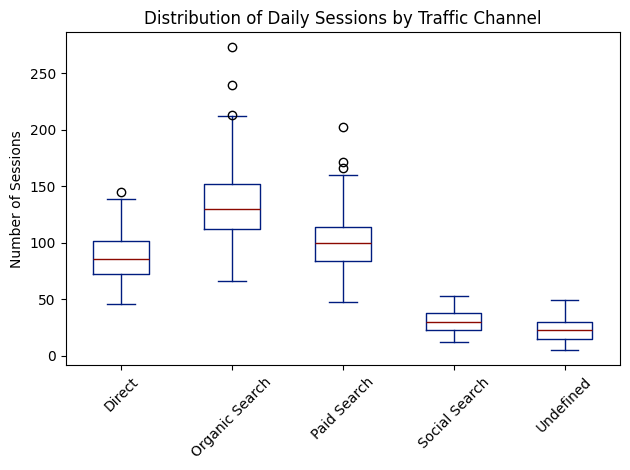

The distributions of sessions per day for each traffic channel likely deviate from normality, and their variances may not be equal. Therefore, the Kruskal-Wallis H-test, a non-parametric alternative to ANOVA, is suitable for comparing these independent groups.


In [ ]:
# Analyze the number of sessions by different traffic channels
sessions_by_channel = df.groupby('traffic_channel')['ga_session_id'].nunique()
print(f"Number of unique sessions by traffic channel:\n{sessions_by_channel}")

# Prepare data for statistical test: sessions per day for each channel
sessions_per_day_by_channel = df.groupby(['date', 'traffic_channel'])['ga_session_id'].nunique().unstack(fill_value=0)

# Visualize the distributions
plt.figure(figsize=(12, 6))
sessions_per_day_by_channel.plot(kind='box', title='Distribution of Daily Sessions by Traffic Channel')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("The distributions of sessions per day for each traffic channel likely deviate from normality, and their variances may not be equal. Therefore, the Kruskal-Wallis H-test, a non-parametric alternative to ANOVA, is suitable for comparing these independent groups.")

In [ ]:
from scipy.stats import kruskal

# Extract session data for each traffic channel as separate arrays
channel_groups = [sessions_per_day_by_channel[channel].values for channel in sessions_per_day_by_channel.columns]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*channel_groups)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Since the p-value ({p_value:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the number of sessions between different traffic channels.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the number of sessions between different traffic channels.")


Kruskal-Wallis H-statistic: 349.43
P-value: 2.334e-74
Conclusion: Since the p-value (2.334e-74) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the number of sessions between different traffic channels.


### Correlation of sales by traffic channel

Pairwise Pearson correlations between daily sales of different traffic channels:
  Direct vs. Organic Search: r = 0.76, p-value = 9.108e-18
  Direct vs. Paid Search: r = 0.72, p-value = 1.513e-15
  Direct vs. Social Search: r = 0.46, p-value = 5.901e-06
  Direct vs. Undefined: r = 0.42, p-value = 3.839e-05
  Organic Search vs. Paid Search: r = 0.81, p-value = 1.756e-21
  Organic Search vs. Social Search: r = 0.43, p-value = 2.348e-05
  Organic Search vs. Undefined: r = 0.44, p-value = 2.238e-05
  Paid Search vs. Social Search: r = 0.45, p-value = 9.696e-06
  Paid Search vs. Undefined: r = 0.43, p-value = 2.897e-05
  Social Search vs. Undefined: r = 0.36, p-value = 5.853e-04


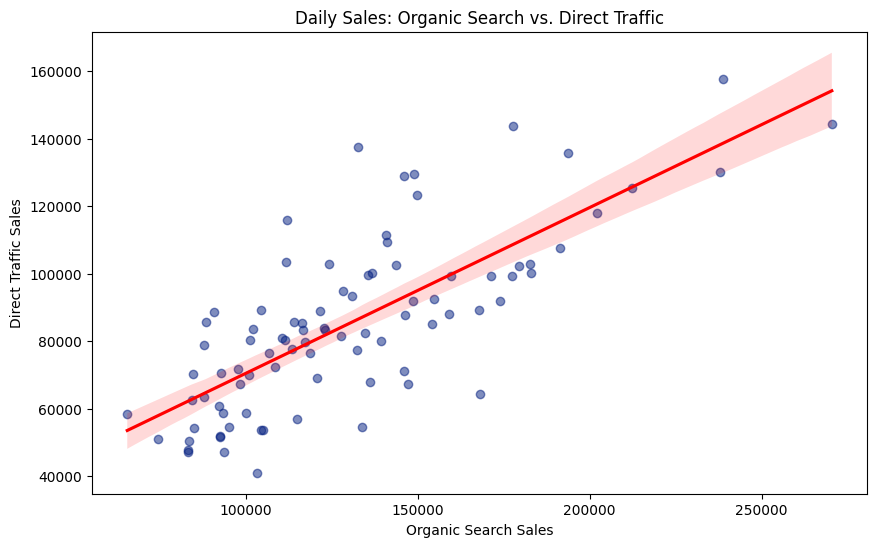

In [ ]:
import itertools

# Prepare data: daily sales for each traffic channel
sales_per_day_by_channel = df.groupby(['date', 'traffic_channel'])['price'].sum().unstack(fill_value=0)

print("Pairwise Pearson correlations between daily sales of different traffic channels:")

# Get all unique traffic channels
traffic_channels = sales_per_day_by_channel.columns

# Calculate pairwise correlations
channel_correlations = {}
for channel1, channel2 in itertools.combinations(traffic_channels, 2):
    correlation, p_value = pearsonr(sales_per_day_by_channel[channel1], sales_per_day_by_channel[channel2])
    channel_correlations[f'{channel1} vs. {channel2}'] = {'correlation': correlation, 'p_value': p_value}
    print(f"  {channel1} vs. {channel2}: r = {correlation:.2f}, p-value = {p_value:.3e}")

# Optional: Visualize a scatter plot for two prominent channels as an example
plt.figure(figsize=(10, 6))
sns.regplot(x=sales_per_day_by_channel['Organic Search'], y=sales_per_day_by_channel['Direct'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Daily Sales: Organic Search vs. Direct Traffic')
plt.xlabel('Organic Search Sales')
plt.ylabel('Direct Traffic Sales')
plt.show()


##Conclusion:


Based on the comprehensive analysis, several key insights into sales dynamics, user behavior, and market trends have been identified:

*   **Strong Correlation between Sessions and Sales:** There is an extremely strong positive linear correlation (Pearson r = 0.96) between the number of unique sessions and total sales. This indicates that an increase in website traffic directly and significantly contributes to higher sales volumes, making session growth a critical driver for revenue.

*   **Inter-Continent Sales Synchronicity:** Daily sales trends among the top 3 continents (Americas, Asia, and Europe) show significant positive correlations (r between 0.67 and 0.69). This suggests that market factors or global events often influence these regions in a similar manner, leading to synchronized daily sales dynamics.

*   **Traffic Channel Sales Dynamics:** Sales across different traffic channels also exhibit strong positive correlations (e.g., Organic Search vs. Direct Traffic, r = 0.76; Organic Search vs. Paid Search, r = 0.81). This implies that various marketing efforts often experience similar performance fluctuations, possibly driven by overarching campaigns or external factors.

*   **Statistical Difference in Sales by User Registration:** The Mann-Whitney U test revealed a statistically significant difference in sales between registered and unregistered users (p-value < 0.05). While subscribed users generate more total sales, unregistered users show a slightly higher average sales per session. This suggests that while registered users contribute significantly to overall revenue, unregistered users might be making larger, more infrequent purchases on average.

*   **Statistical Difference in Sessions by Traffic Channel:** The Kruskal-Wallis H-test demonstrated a statistically significant difference in the number of sessions between different traffic channels (p-value < 0.05). This confirms that traffic channels do not contribute equally to session volume, highlighting the varying effectiveness or reach of each channel.

*   **Seasonal Trends:** Weekly sales analysis indicates fluctuations, but the current data period (3 months) is insufficient to determine annual or quarterly seasonal patterns. Further data collection is recommended for a more robust seasonal analysis.

In summary, the analysis underscores the importance of driving website traffic, optimizing strategies for different traffic channels, and understanding user behavior nuances to maximize sales. The strong correlations observed across various dimensions provide a solid foundation for predictive modeling and strategic planning.
